# Data Mining Lab 1
## Data Understanding + Data Cleaning + Visualization  
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
- Бодит dataset ашиглан өгөгдлийг унших, таних  
- Алдаа, дутуу утга, давхардлыг шалгаж цэвэрлэх  
- Энгийн график дүрслэлээр pattern-ийг олж харах  



In [18]:
%pip install numpy matplotlib pandas

318.51s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 2.0 MB/s eta 0:00:00m eta 0:00:010:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 1.5 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.9 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 1.8 MB/s eta 0:00:001.9 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.4 MB/s eta 0:00:003.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 1.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.1 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 2.1 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 1.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 3.0 MB/s eta 0:00:003.1 MB/s eta 0:00:01

[n

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Data Understanding (өгөгдлөө таних)

### 1.1 Dataset-ийн бүтэц
- Хэдэн мөр, хэдэн баганатай вэ?  
- Аль баганууд numeric байна вэ?  
- Аль багана нь ирээдүйд prediction хийхэд тохиромжтой вэ?


In [3]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.dtypes


Shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль баганад missing value байна вэ?  
- Давхардсан мөр байгаа эсэх?


In [4]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Үндсэн статистик

Эндээс:
- Math, Reading, Writing score-уудын ерөнхий тархалтыг харна  
- Аль score хамгийн өндөр дундажтай байна вэ?


In [ ]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [14]:
df.groupby('lunch')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



1. Gender ба score-уудын хооронд ялгаа байна уу? (таамаг)  
2. Lunch төрлөөс score хамаарах уу?  
3. Аль score (math, reading, writing) хамгийн тогтвортой мэт харагдаж байна вэ?


## 2) Data Cleaning (өгөгдөл цэвэрлэх)

Энэ dataset-д ихэнхдээ missing бага эсвэл байхгүй байдаг.  
Гэхдээ дараах алхмуудыг **заавал шалгана**:

- Missing value  
- Category data-г ялгаж харах  
- Numeric data-г тусад нь авч үзэх


In [15]:
# Numeric болон categorical баганууд
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 3) Visualization (график дүрслэл)

Энд бид өгөгдөл доторх **pattern-ийг нүдээрээ олж харна**.


### 3.1 Histogram – Math score
- Дийлэнх оюутнууд аль score орчимд байна вэ?


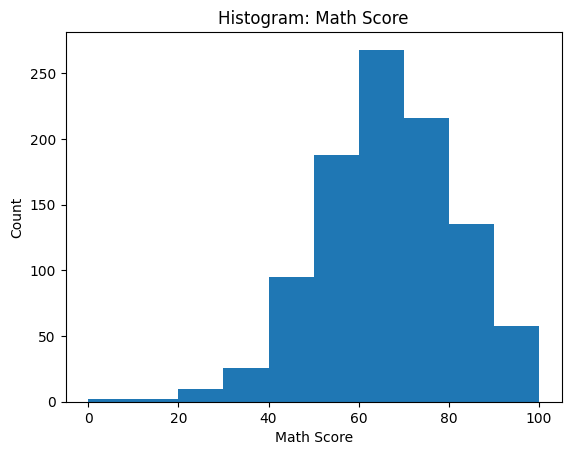

In [ ]:
plt.figure()
plt.hist(df['math score'], bins=10)
plt.title("Histogram: Math Score")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()


### 3.2 Scatter – Math vs Reading
- Эдгээр хоёр score хоорондоо холбоотой юу?


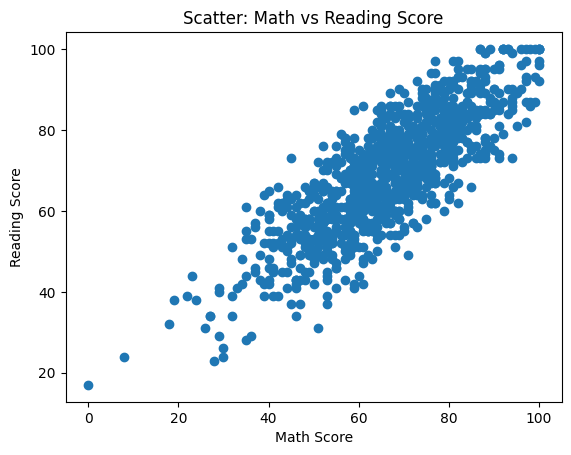

In [ ]:
plt.figure()
plt.scatter(df['math score'], df['reading score'])
plt.title("Scatter: Math vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()


### 3.3 Boxplot – Gender vs Math Score
- Gender хооронд ялгаа ажиглагдаж байна уу?


<Figure size 640x480 with 0 Axes>

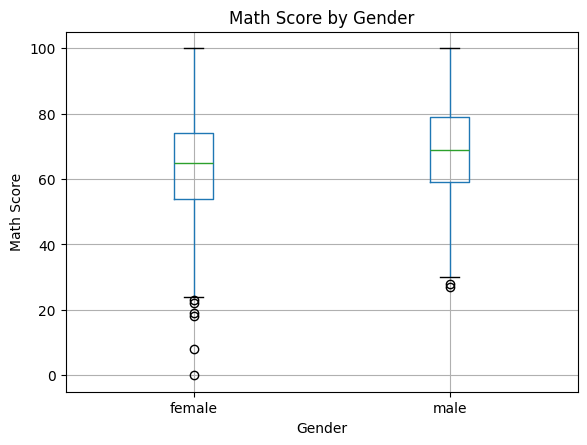

In [16]:
plt.figure()
df.boxplot(column='math score', by='gender')
plt.title("Math Score by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()


### 3.4 Correlation Heatmap (numeric features)

- Math, Reading, Writing score-уудын correlation-ийг харна  
- Аль хоёр нь хамгийн өндөр холбоотой вэ?


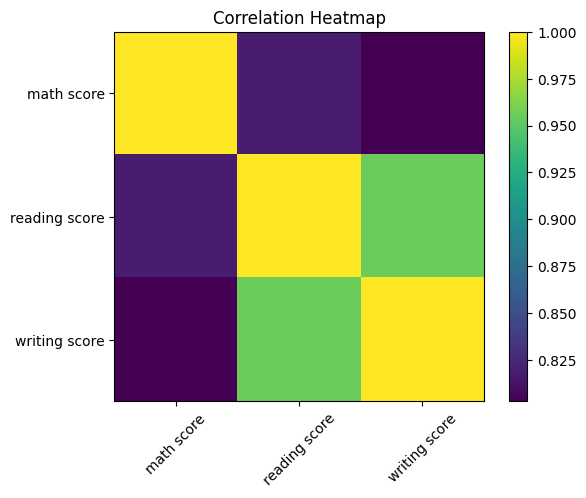

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [17]:
scores = df[['math score','reading score','writing score']]
corr = scores.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(scores.columns)), scores.columns, rotation=45)
plt.yticks(range(len(scores.columns)), scores.columns)
plt.title("Correlation Heatmap")
plt.show()

corr


## TASK A: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь
   math score-т хамгийн их ялгаа үүсгэж байна вэ?
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол.
3. Ямар feature нь prediction хийхэд илүү ашигтай санагдаж байна вэ? (үгээр)

`groupby()` + `mean()` ашиглана уу.


In [27]:
# code
gender_mean = df.groupby('gender')['math score'].mean()
lunch_mean = df.groupby('lunch')['math score'].mean()
test_mean = df.groupby('test preparation course')['math score'].mean()
gender_diff = gender_mean.max() - gender_mean.min()
lunch_diff = lunch_mean.max() - lunch_mean.min()
test_diff = test_mean.max() - test_mean.min()
print(f"Gender diff {gender_diff}")
print(f"Lunch diff : {lunch_diff}")
print(f"Test preparation diff : {test_diff}")

Gender diff 5.095011134430216
Lunch diff : 11.112981766568396
Test preparation diff : 5.617649106319291


##  TASK B: Score Comparison

1. Math, Reading, Writing score-уудын **variance** (эсвэл std)-ийг тооцоол.
2. Аль score хамгийн их хэлбэлзэлтэй байна вэ?
3. Энэ нь суралцахад юуг илэрхийлж болох вэ? (үгээр)

 `var()` эсвэл `std()` ашиглана уу.


In [28]:
# code
scores = ['math score','writing score', 'reading score']
df[scores].agg(['std','var'])

,math score,writing score,reading score
std,15.163080,15.195657,14.600192
var,229.918998,230.907992,213.165605


## TASK C: Simple Rule Thinking

Доорх энгийн дүрмүүдийг шалгаарай.

1. Math score ≥ 70 оюутнуудын дундаж Reading score хэд вэ?
2. Math score < 70 оюутнуудын дундаж Reading score хэд вэ?
3. Эдгээрийн ялгаа нь ямар **pattern**-ийг харуулж байна вэ?

Boolean filter + `mean()` ашиглана уу.


In [ ]:
# code
high_math_read = df[df['math score'] >= 70]['reading score'].mean()
low_math_read = df[df['math score'] < 70]['reading score'].mean()
print(f"High math read : {high_math_read}")
print(f"Low mathr read : {low_math_read}")
diff = high_math_read - low_math_read
print(f"Diff {diff}")

High math read : 80.25916870415648
Low mathr read : 61.49407783417936
Diff 18.765090869977122


# Data Mining Lab 1 Тайлан 
## Student Performance Dataset

**Нэр:**  
**Оюутны код:**  
**Анги / Бүлэг:**  
**Огноо:**  

---

## 1. Dataset-ийн ерөнхий мэдээлэл
- Мөрийн тоо:
- Баганын тоо:
- Target variable (хэрэв байвал):

Dataset-ийг 2–3 өгүүлбэрээр тайлбарлана уу.

---

## 2. Data Understanding (Өгөгдөл таних)

### Numeric Features
Numeric багануудыг жагсааж, утгыг тайлбарлана уу.

### Categorical Features
Categorical багануудыг жагсааж, утгыг тайлбарлана уу.

`describe()`-оос ажиглагдсан гол зүйлс:

---

## 3. Data Cleaning (Өгөгдөл цэвэрлэгээ)
- Missing value байсан уу? (Тийм / Үгүй)
- Хэрхэн шийдсэн бэ?
- Duplicate мөр байсан уу? (Тийм / Үгүй)

Цэвэрлэгээний шийдвэрээ 2–3 өгүүлбэрээр тайлбарлана уу.

---

## 4. Visualization ба Pattern

### Visualization 1
- Төрөл (Histogram / Scatter / Boxplot):
- Ажиглагдсан pattern:

### Visualization 2
- Төрөл:
- Ажиглагдсан pattern:

---

## 5. Correlation Analysis
- Хамгийн өндөр correlation-той хос:
- Энэ нь юуг илэрхийлж байна вэ?

---

## 6. Дүгнэлт
Энэ лабораториос сурсан зүйлээ 3–4 өгүүлбэрээр дүгнэнэ үү.

---

